In [ ]:
# Mount your google drive in google colab
from google.colab import drive
drive.mount('/content/drive')

#depend. problem with rich 13.3

!pip install torch==1.13.1
!pip install torchaudio==0.13.1
!pip install torchmetrics==0.11.4
!pip install torchsummary==1.5.1
!pip install torchtext==0.14.1
!pip install torchvision==0.14.1
!pip install rich==13.2
import rich
!pip install matplotlib==3.5.3
!pip install --quiet scvi-colab==0.11.0


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.5/887.5 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 67.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 71.8 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.1.0+cu121
    Uninstalling torch-2.1.0+cu121:
      Successfully uninstalled torch-2.1.0+cu121
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.1.0+cu121 requires torch==2.1.0, but you have torch 1.13.1 which is incompatible.
torchdata 0.7.0 requires torch==2.1.0, but you have torch 1.13.1 which is incompatible.
torchtext 0.16.0 requires torch==2.1.0, 

In [ ]:
from scvi_colab import install
install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scvi
import scanpy as sc
import pandas as pd
import scipy
from scipy.stats import pearsonr

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/SusztakLabFiles/CosMx/adata/fetal/fetal_annotated_AllCells_preSCVI_final.h5ad")

In [ ]:
adata.obs["tech"].value_counts()

adata.X = adata.layers["counts"]

In [ ]:
adata.obs['phase'] = adata.obs['phase'].fillna(0)
adata.obs['G2M_score'] = adata.obs['G2M_score'].fillna(0)
adata.obs['S_score'] = adata.obs['S_score'].fillna(0)
adata.obs['nCount_RNA'] = adata.obs['nCount_RNA'].fillna(0)
adata.obs['total_counts'] = adata.obs['total_counts'].fillna(0)
adata.obs['pct_nuc'] = adata.obs['pct_nuc'].fillna(0)
adata.obs['Area'] = adata.obs['Area'].fillna(0)
adata.obs['pct_counts_mt'] = adata.obs['pct_counts_mt'].fillna(0)
adata.obs['AllCounts'] = adata.obs['nCount_RNA'] + adata.obs['total_counts']

In [ ]:
adata= adata.copy()

scvi.model.SCVI.setup_anndata(
    adata,
    batch_key="tech",
    layer="counts", categorical_covariate_keys=["sample"],
    continuous_covariate_keys=["Count_percentile","pct_counts_mt","G2M_score","S_score"])

model = scvi.model.SCVI(adata)
model
vae = scvi.model.SCVI(adata, n_layers=5, n_latent=30, gene_likelihood="nb", dropout_rate=0.1)
vae.train(max_epochs = 1000, plan_kwargs={"lr":0.001}, early_stopping = True)
model = vae

/usr/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:

Epoch 1/1000:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


Epoch 419/1000:  42%|████▏     | 419/1000 [6:58:14<9:39:56, 59.89s/it, v_num=1, train_loss_step=320, train_loss_epoch=314]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 313.260. Signaling Trainer to stop.


In [ ]:
model.save("/content/drive/MyDrive/SusztakLabFiles/CosMx/models/fetal_model_2b/")
vae = scvi.model.SCVI.load("/content/drive/MyDrive/SusztakLabFiles/CosMx/models/fetal_model_2b/", adata=adata, use_gpu=False)

INFO     File /content/drive/MyDrive/SusztakLabFiles/CosMx/models/fetal_model_2b/model.pt already downloaded       


/usr/local/lib/python3.10/dist-packages/scvi/model/base/_base_model.py:676: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


In [ ]:
adata.obsm["X_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata)
sc.tl.umap(adata)

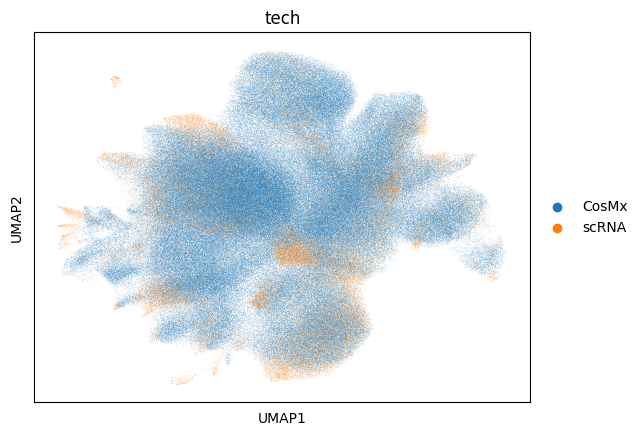

In [ ]:
sc.pl.umap(adata, color = "tech")

In [ ]:
adata.write_h5ad(filename = "/content/drive/MyDrive/SusztakLabFiles/CosMx/adata/fetal/fetal_annotated_AllCells_model2b_postSCVI.h5ad")
